# 10 — Event amplitudes and acoustic–seismic coupling

Measure component and three-component vector PGV, aligned median-stack pressure
amplitudes, reduced pressure, signal-to-noise ratios, and acoustic-to-seismic
amplitude ratios for all Notebook 07 events. Planar selection tiers from
Notebook 08 are retained as descriptive overlays; regression uses independent
measurement-quality thresholds.


In [1]:
from __future__ import annotations

import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import LogNorm
from matplotlib.ticker import FuncFormatter
from obspy import read
from scipy.stats import linregress

project_root = Path.cwd().resolve()
if project_root.name == "notebooks2":
    project_root = project_root.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from modules import project_config as config

PREPARATION_ROOT = config.OUTPUT_DIR / "candidate_airwave_preparation"
PLANAR_ROOT = config.OUTPUT_DIR / "array_analysis_planar_refined"

OUTPUT_ROOT = config.OUTPUT_DIR / "event_amplitude_coupling"
FIGURE_DIR = OUTPUT_ROOT / "figures"
DIAGNOSTIC_DIR = OUTPUT_ROOT / "event_diagnostics"

for directory in (
    OUTPUT_ROOT,
    FIGURE_DIR,
    DIAGNOSTIC_DIR,
):
    directory.mkdir(parents=True, exist_ok=True)

CANDIDATE_CATALOGUE_FILE = (
    PREPARATION_ROOT
    / "derived"
    / "candidate_airwave_event_catalogue.csv"
)
FILTER_DECISIONS_FILE = PLANAR_ROOT / "event_filter_decisions.csv"
PLANAR_RESULTS_FILE = PLANAR_ROOT / "planar_array_results.csv"
EVENT_STREAM_DIR = PREPARATION_ROOT / "event_streams"

ANALYSIS_CONFIG_FILE = config.OUTPUT_DIR / "02_analysis_configuration.json"
WEATHER_SUMMARY_FILE = config.OUTPUT_DIR / "03_weather_acoustic_summary.csv"

for required_file in (
    ANALYSIS_CONFIG_FILE,
    WEATHER_SUMMARY_FILE,
):
    if not required_file.exists():
        raise FileNotFoundError(required_file)

analysis_config = json.loads(ANALYSIS_CONFIG_FILE.read_text())
GEOMETRY_FILE = Path(
    analysis_config["geometry_file"]
).expanduser()
if not GEOMETRY_FILE.exists():
    raise FileNotFoundError(
        "Geometry product recorded by Notebook 02 was not found: "
        f"{GEOMETRY_FILE}"
    )
geometry = pd.read_csv(GEOMETRY_FILE)
weather_summary = pd.read_csv(WEATHER_SUMMARY_FILE).iloc[0]

SEISMIC_CHANNELS = ("DHZ", "DHN", "DHE")
SEISMIC_LABELS = {"DHZ": "Vertical", "DHN": "North", "DHE": "East"}
INFRASOUND_CHANNELS = ("DD1", "DD2", "DD3")
INFRASOUND_DISTANCES_M = (
    geometry.loc[geometry["channel"].isin(INFRASOUND_CHANNELS)]
    .set_index("channel")["distance_m"].astype(float).to_dict()
)
ACOUSTIC_ALIGNMENT_SPEED_MPS = float(
    weather_summary["effective_sound_speed_mps"]
)
ACOUSTIC_REFERENCE_CHANNEL = analysis_config["infrasound_reference_channel"]

# Times are relative to each event's reduced/reference time.
NOISE_WINDOW_S = (-0.18, -0.05)
DEFAULT_SIGNAL_PADDING_S = 0.0
PRINCIPAL_EXPLOSION_EVENT_NUMBER = 13
PRINCIPAL_SIGNAL_WINDOW_S = (-0.04, 0.35)

# Approximate distance used only for optional reduced-pressure columns.
REFERENCE_SOURCE_DISTANCE_M = float(analysis_config["array_reference"]["distance_m"])
REDUCED_PRESSURE_REFERENCE_DISTANCE_M = 1000.0

# Constant p2p-pressure/PGV ratios shown on the log-log comparison.
# Units are Pa / (m s^-1).
RATIO_GUIDES_PA_PER_MPS = (1e5, 1e6, 1e7, 1e8, 1e9)

# Optional diagnostic waveform plots. Set to an integer to limit their number.
MAKE_EVENT_DIAGNOSTICS = True
MAX_DIAGNOSTIC_EVENTS: int | None = None

plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 240,
    "axes.spines.top": False,
    "axes.spines.right": False,
})


## Load and combine existing event metadata

The candidate catalogue supplies the acoustic measurements and event intervals.
The refined planar products supply the permissive/core selection labels and
coherence results. Events are retained even when they did not pass the planar
analysis filter, so amplitude trends can be examined without treating that
filter as a physical boundary.


In [2]:
for required in (CANDIDATE_CATALOGUE_FILE,):
    if not required.exists():
        raise FileNotFoundError(required)

events = pd.read_csv(CANDIDATE_CATALOGUE_FILE)
events = events.rename(columns={"candidate_event_number": "event_number"})
events["event_number"] = events["event_number"].astype(int)
events["event_time"] = pd.to_datetime(events["reduced_event_epoch_s"], unit="s", utc=True)

if FILTER_DECISIONS_FILE.exists():
    decisions = pd.read_csv(FILTER_DECISIONS_FILE)
    keep = [
        "event_number", "event_label", "forced_named_event",
        "passes_analysis_filter", "passes_core_filter", "analysis_filter_reason",
    ]
    events = events.merge(decisions[[c for c in keep if c in decisions]], on="event_number", how="left")
else:
    events["event_label"] = "candidate"
    events["forced_named_event"] = False
    events["passes_analysis_filter"] = False
    events["passes_core_filter"] = False
    events["analysis_filter_reason"] = "planar decisions unavailable"

if PLANAR_RESULTS_FILE.exists():
    planar = pd.read_csv(PLANAR_RESULTS_FILE)
    planar_keep = [
        "event_number", "best_back_azimuth_deg", "best_apparent_speed_mps",
        "maximum_coherence_score", "solution_quality_class",
    ]
    events = events.merge(planar[[c for c in planar_keep if c in planar]], on="event_number", how="left")

for column in ("forced_named_event", "passes_analysis_filter", "passes_core_filter"):
    if column not in events:
        events[column] = False
    events[column] = events[column].fillna(False).astype(bool)

events["selection_tier"] = np.select(
    [events["passes_core_filter"], events["passes_analysis_filter"]],
    ["core", "additional_analyzed"],
    default="other_candidate",
)

events = events.sort_values("reduced_event_epoch_s").reset_index(drop=True)
events["elapsed_time_s"] = events["reduced_event_epoch_s"] - events["reduced_event_epoch_s"].min()
events["elapsed_time_min"] = events["elapsed_time_s"] / 60.0

print(f"Loaded {len(events)} candidate events")
display(events["selection_tier"].value_counts().rename_axis("tier").to_frame("events"))
display(events.head())


Loaded 153 candidate events


,events
tier,
core,76
additional_analyzed,67
other_candidate,10


,reconstructed_event_number,reduced_event_epoch_s,first_reduced_pick_epoch_s,last_reduced_pick_epoch_s,corrected_pick_span_s,pick_count,channel_count,channels,pick_indices,observed_first_pick_epoch_s,...,passes_analysis_filter,passes_core_filter,analysis_filter_reason,best_back_azimuth_deg,best_apparent_speed_mps,maximum_coherence_score,solution_quality_class,selection_tier,elapsed_time_s,elapsed_time_min
0,1,1.472735e+09,1.472735e+09,1.472735e+09,0.002107,3,3,"DD1,DD2,DD3","198,193,194",1.472735e+09,...,True,True,pass,200.9,352.5,0.979982,A_high_quality,core,0.000000,0.000000
1,2,1.472735e+09,1.472735e+09,1.472735e+09,0.011107,3,3,"DD1,DD2,DD3","201,199,200",1.472735e+09,...,True,True,pass,201.6,355.5,0.961110,A_high_quality,core,0.130000,0.002167
2,3,1.472735e+09,1.472735e+09,1.472735e+09,0.003760,3,3,"DD1,DD2,DD3","204,202,203",1.472735e+09,...,True,True,pass,201.3,352.5,0.957236,A_high_quality,core,0.327867,0.005464
3,4,1.472735e+09,1.472735e+09,1.472735e+09,0.029866,2,2,"DD2,DD3","206,205",1.472735e+09,...,True,False,pass,201.6,307.0,0.857361,C_weak_or_broad,additional_analyzed,0.519933,0.008666
4,5,1.472735e+09,1.472735e+09,1.472735e+09,0.000866,2,2,"DD2,DD3","207,208",1.472735e+09,...,True,False,pass,200.7,359.0,0.806525,B_probable,additional_analyzed,0.872433,0.014541


## PGV measurement

For each seismic component, a constant local baseline is estimated as the median
ground velocity in the pre-event noise interval. That baseline is subtracted
before measuring amplitudes. This avoids allowing the event itself to influence
an all-window demean or linear detrend.

The primary seismic amplitude is

\[
\mathrm{PGV}_{3C}=\max_t\sqrt{v_E(t)^2+v_N(t)^2+v_Z(t)^2}.
\]

Component PGVs and the vector PGV are measured over the acoustic event interval.
An entire-segment PGV is also retained as a diagnostic; it is not the preferred
catalogue value because it may include neighboring signals or coda.


In [3]:
def robust_sigma(values):
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]
    if values.size == 0:
        return np.nan
    median = np.nanmedian(values)
    return float(1.4826 * np.nanmedian(np.abs(values - median)))


def trace_relative_times(trace, reference_epoch_s):
    start_offset = float(trace.stats.starttime.timestamp) - float(reference_epoch_s)
    return start_offset + np.arange(trace.stats.npts, dtype=float) / float(trace.stats.sampling_rate)


def interpolate_trace(trace, reference_epoch_s, target_times_s):
    times = trace_relative_times(trace, reference_epoch_s)
    values = np.asarray(trace.data, dtype=float)
    return np.interp(target_times_s, times, values, left=np.nan, right=np.nan)


def signal_window_for_event(row):
    if int(row.event_number) == PRINCIPAL_EXPLOSION_EVENT_NUMBER:
        return PRINCIPAL_SIGNAL_WINDOW_S
    start = float(row.event_start_s) - DEFAULT_SIGNAL_PADDING_S
    end = float(row.event_end_s) + DEFAULT_SIGNAL_PADDING_S
    if not np.isfinite(start) or not np.isfinite(end) or end <= start:
        # Conservative fallback centered on the associated arrival.
        return (-0.04, 0.18)
    return (start, end)


def measure_event_pgv(row):
    stream_path = Path(row.segment_path)
    if not stream_path.exists():
        stream_path = EVENT_STREAM_DIR / row.segment_file
    if not stream_path.exists():
        raise FileNotFoundError(stream_path)

    stream = read(str(stream_path), format="PICKLE")
    reference_epoch_s = float(row.reduced_event_epoch_s)
    signal_start_s, signal_end_s = signal_window_for_event(row)

    traces = {}
    for channel in SEISMIC_CHANNELS:
        matches = stream.select(channel=channel)
        if len(matches) != 1:
            raise ValueError(f"Expected one {channel} trace in {stream_path}; found {len(matches)}")
        traces[channel] = matches[0]

    acoustic_traces = {}
    for channel in INFRASOUND_CHANNELS:
        matches = stream.select(channel=channel)
        if len(matches) != 1:
            raise ValueError(f"Expected one {channel} trace in {stream_path}; found {len(matches)}")
        acoustic_traces[channel] = matches[0]

    sampling_rates = [float(trace.stats.sampling_rate) for trace in traces.values()]
    sampling_rate_hz = min(sampling_rates)
    dt = 1.0 / sampling_rate_hz

    reference_distance_m = INFRASOUND_DISTANCES_M[ACOUSTIC_REFERENCE_CHANNEL]
    # The primary grid is the common overlap of the three seismic channels.
    # Shifted pressure traces may have NaNs at an edge; nanmedian then retains
    # the available sensors instead of shortening a valid late event window.
    common_start_s = max(trace_relative_times(trace, reference_epoch_s)[0] for trace in traces.values())
    common_end_s = min(trace_relative_times(trace, reference_epoch_s)[-1] for trace in traces.values())
    target_times_s = np.arange(common_start_s, common_end_s, dt)

    corrected = {}
    baselines = {}
    noise_scales = {}
    component_pgv = {}
    component_peak_time = {}

    signal_mask = (target_times_s >= signal_start_s) & (target_times_s <= signal_end_s)
    noise_mask = (target_times_s >= NOISE_WINDOW_S[0]) & (target_times_s <= NOISE_WINDOW_S[1])
    if np.count_nonzero(signal_mask) < 2:
        raise ValueError(f"No usable signal samples for event {row.event_number}")
    if np.count_nonzero(noise_mask) < 2:
        raise ValueError(f"No usable noise samples for event {row.event_number}")

    for channel, trace in traces.items():
        values = interpolate_trace(trace, reference_epoch_s, target_times_s)
        baseline = float(np.nanmedian(values[noise_mask]))
        centered = values - baseline
        corrected[channel] = centered
        baselines[channel] = baseline
        noise_scales[channel] = robust_sigma(centered[noise_mask])
        signal_values = centered[signal_mask]
        local_index = int(np.nanargmax(np.abs(signal_values)))
        component_pgv[channel] = float(np.abs(signal_values[local_index]))
        component_peak_time[channel] = float(target_times_s[signal_mask][local_index])

    matrix = np.vstack([corrected[channel] for channel in SEISMIC_CHANNELS])
    vector_velocity = np.sqrt(np.nansum(matrix ** 2, axis=0))
    vector_signal = vector_velocity[signal_mask]
    vector_index = int(np.nanargmax(vector_signal))
    vector_pgv = float(vector_signal[vector_index])
    vector_pgv_time_s = float(target_times_s[signal_mask][vector_index])
    segment_vector_pgv = float(np.nanmax(vector_velocity))

    vector_noise_scale = float(np.sqrt(np.nansum(np.square(list(noise_scales.values())))))
    vector_snr = vector_pgv / vector_noise_scale if vector_noise_scale > 0 else np.nan

    # Align baseline-corrected pressure traces to DD2 using the provisional
    # differential delays established in Notebook 07, then measure the stack.
    aligned_pressure = []
    for channel in INFRASOUND_CHANNELS:
        delay_s = (INFRASOUND_DISTANCES_M[channel] - reference_distance_m) / ACOUSTIC_ALIGNMENT_SPEED_MPS
        aligned_pressure.append(
            interpolate_trace(acoustic_traces[channel], reference_epoch_s, target_times_s + delay_s)
        )
    aligned_pressure = np.vstack(aligned_pressure)
    median_pressure_stack = np.nanmedian(aligned_pressure, axis=0)
    acoustic_signal = median_pressure_stack[signal_mask]
    acoustic_positive_peak = float(np.nanmax(acoustic_signal))
    acoustic_negative_peak = float(np.nanmin(acoustic_signal))
    acoustic_peak_to_peak = acoustic_positive_peak - acoustic_negative_peak
    acoustic_noise_scale = robust_sigma(median_pressure_stack[noise_mask])
    acoustic_stack_snr = (
        acoustic_peak_to_peak / acoustic_noise_scale if acoustic_noise_scale > 0 else np.nan
    )

    result = {
        "event_number": int(row.event_number),
        "stream_file": str(stream_path),
        "seismic_signal_start_s": signal_start_s,
        "seismic_signal_end_s": signal_end_s,
        "seismic_signal_duration_s": signal_end_s - signal_start_s,
        "seismic_noise_start_s": NOISE_WINDOW_S[0],
        "seismic_noise_end_s": NOISE_WINDOW_S[1],
        "sampling_rate_hz": sampling_rate_hz,
        "pgv_hhz_mps": component_pgv["DHZ"],
        "pgv_hhn_mps": component_pgv["DHN"],
        "pgv_hhe_mps": component_pgv["DHE"],
        "pgv_vector_mps": vector_pgv,
        "pgv_vector_time_s": vector_pgv_time_s,
        "pgv_entire_segment_vector_mps": segment_vector_pgv,
        "pgv_vector_snr": vector_snr,
        "noise_hhz_mps": noise_scales["DHZ"],
        "noise_hhn_mps": noise_scales["DHN"],
        "noise_hhe_mps": noise_scales["DHE"],
        "noise_vector_mps": vector_noise_scale,
        "baseline_hhz_mps": baselines["DHZ"],
        "baseline_hhn_mps": baselines["DHN"],
        "baseline_hhe_mps": baselines["DHE"],
        "acoustic_stack_positive_peak_pa": acoustic_positive_peak,
        "acoustic_stack_negative_peak_pa": acoustic_negative_peak,
        "acoustic_stack_peak_to_peak_pa": acoustic_peak_to_peak,
        "acoustic_stack_noise_pa": acoustic_noise_scale,
        "acoustic_stack_p2p_snr": acoustic_stack_snr,
    }
    return result, {
        "times_s": target_times_s,
        "corrected": corrected,
        "vector_velocity": vector_velocity,
        "median_pressure_stack": median_pressure_stack,
        "signal_window": (signal_start_s, signal_end_s),
    }


## Measure every event and assemble the catalogue

The pressure/PGV ratios below use the median-stack acoustic measurements from
Notebook 07 and the coincident vector PGV measured here. The units are retained
explicitly:

\[
R_{P/V}=\frac{p_{p2p}}{\mathrm{PGV}_{3C}}
\quad [\mathrm{Pa}\,(\mathrm{m\,s^{-1}})^{-1}].
\]


In [4]:
pgv_rows = []
diagnostic_data = {}
errors = []

for row in events.itertuples(index=False):
    try:
        result, diagnostic = measure_event_pgv(row)
        pgv_rows.append(result)
        diagnostic_data[int(row.event_number)] = diagnostic
    except Exception as exc:
        errors.append({"event_number": int(row.event_number), "error": str(exc)})

pgv = pd.DataFrame(pgv_rows)
measurements = events.merge(pgv, on="event_number", how="left")

measurements["reduced_peak_to_peak_pa_1km"] = measurements["acoustic_stack_peak_to_peak_pa"] * (
    REFERENCE_SOURCE_DISTANCE_M / REDUCED_PRESSURE_REFERENCE_DISTANCE_M
)
measurements["p2p_pressure_to_vector_pgv"] = (
    measurements["acoustic_stack_peak_to_peak_pa"] / measurements["pgv_vector_mps"]
)
measurements["positive_pressure_to_vector_pgv"] = (
    measurements["acoustic_stack_positive_peak_pa"] / measurements["pgv_vector_mps"]
)
measurements["reduced_p2p_pressure_to_vector_pgv"] = (
    measurements["reduced_peak_to_peak_pa_1km"] / measurements["pgv_vector_mps"]
)
measurements["pgv_window_capture_fraction"] = (
    measurements["pgv_vector_mps"] / measurements["pgv_entire_segment_vector_mps"]
)

measurements.to_csv(OUTPUT_ROOT / "event_acoustic_seismic_amplitudes.csv", index=False)
pd.DataFrame(errors).to_csv(OUTPUT_ROOT / "pgv_measurement_errors.csv", index=False)

print(f"Measured PGV for {len(pgv_rows)} of {len(events)} events")
if errors:
    display(pd.DataFrame(errors))
display(measurements[[
    "event_number", "event_time", "selection_tier", "acoustic_stack_peak_to_peak_pa",
    "pgv_vector_mps", "pgv_vector_snr", "p2p_pressure_to_vector_pgv",
]].head())


Measured PGV for 153 of 153 events


,event_number,event_time,selection_tier,acoustic_stack_peak_to_peak_pa,pgv_vector_mps,pgv_vector_snr,p2p_pressure_to_vector_pgv
0,1,2016-09-01 13:07:15.927133560+00:00,core,51.381688,0.000133,8.062819,384962.609530
1,2,2016-09-01 13:07:16.057133436+00:00,core,43.905906,0.000078,5.771543,559316.143079
2,3,2016-09-01 13:07:16.255000114+00:00,core,47.556667,0.000136,2.750814,349473.695360
3,4,2016-09-01 13:07:16.447066784+00:00,additional_analyzed,36.497368,0.000123,1.743728,297451.316406
4,5,2016-09-01 13:07:16.799566746+00:00,additional_analyzed,36.727156,0.000087,1.441601,422026.645922


## Amplitudes and coupling through time

Marker style preserves the distinction between the original core selection, the
additional permissive planar-analysis events, and other manual candidates. This
lets us inspect a continuum without pretending that the filtering thresholds are
sharp physical boundaries.


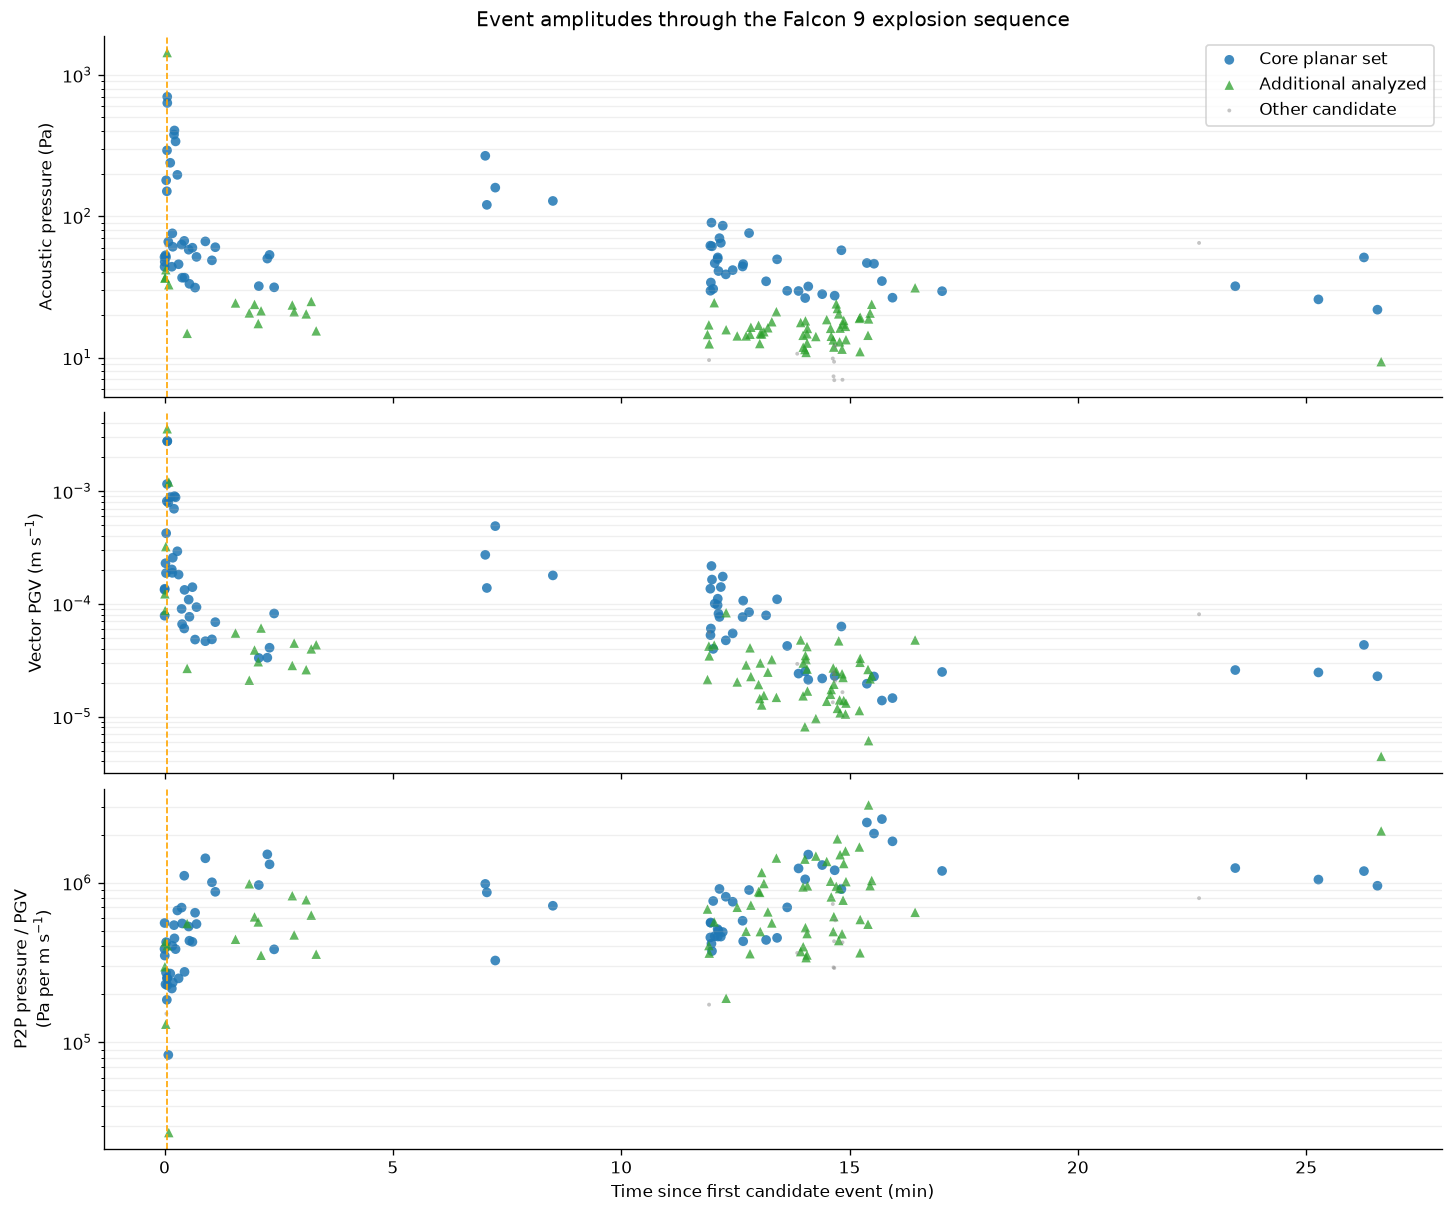

In [5]:
TIER_STYLE = {
    "core": dict(marker="o", s=34, alpha=0.85, color="tab:blue", label="Core planar set"),
    "additional_analyzed": dict(marker="^", s=32, alpha=0.75, color="tab:green", label="Additional analyzed"),
    "other_candidate": dict(marker=".", s=22, alpha=0.45, color="0.5", label="Other candidate"),
}


def scatter_by_tier(ax, frame, x, y):
    artist = None
    for tier, style in TIER_STYLE.items():
        subset = frame.loc[frame["selection_tier"] == tier]
        if subset.empty:
            continue
        kwargs = style.copy()
        artist = ax.scatter(subset[x], subset[y], edgecolor="none", **kwargs)
    return artist


fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True, constrained_layout=True)
scatter_by_tier(axes[0], measurements, "elapsed_time_min", "acoustic_stack_peak_to_peak_pa")
axes[0].set_yscale("log")
axes[0].set_ylabel("Acoustic pressure (Pa)")
axes[0].set_title("Event amplitudes through the Falcon 9 explosion sequence")
axes[0].legend()

scatter_by_tier(axes[1], measurements, "elapsed_time_min", "pgv_vector_mps")
axes[1].set_yscale("log")
axes[1].set_ylabel("Vector PGV (m s$^{-1}$)")

scatter_by_tier(axes[2], measurements, "elapsed_time_min", "p2p_pressure_to_vector_pgv")
axes[2].set_yscale("log")
axes[2].set_ylabel("P2P pressure / PGV\n(Pa per m s$^{-1}$)")
axes[2].set_xlabel("Time since first candidate event (min)")

for ax in axes:
    ax.grid(True, which="both", axis="y", alpha=0.2)
    principal = measurements.loc[measurements["event_number"] == PRINCIPAL_EXPLOSION_EVENT_NUMBER]
    if not principal.empty:
        ax.axvline(float(principal.iloc[0]["elapsed_time_min"]), color="orange", ls="--", lw=1)

fig.savefig(FIGURE_DIR / "acoustic_seismic_amplitudes_vs_time.png", bbox_inches="tight")
plt.show()


## Peak-to-peak pressure versus vector PGV

On logarithmic axes, a constant pressure/PGV amplitude ratio is a line of slope
one:

\[
p_{p2p}=R_{P/V}\,\mathrm{PGV}_{3C}.
\]

The guide lines make relative atmospheric versus ground coupling visually
explicit. They are not detection thresholds or energy-ratio contours.


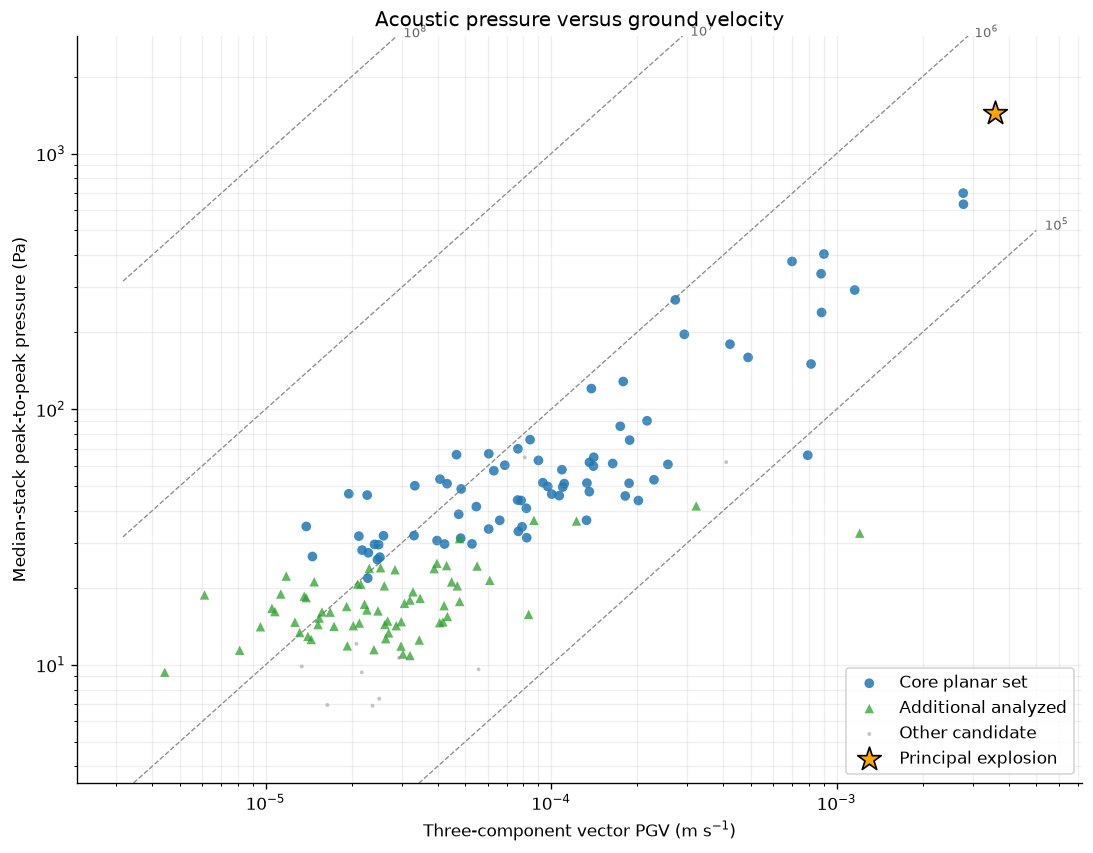

In [6]:
valid = measurements.loc[
    np.isfinite(measurements["acoustic_stack_peak_to_peak_pa"])
    & (measurements["acoustic_stack_peak_to_peak_pa"] > 0)
    & np.isfinite(measurements["pgv_vector_mps"])
    & (measurements["pgv_vector_mps"] > 0)
].copy()

fig, ax = plt.subplots(figsize=(9, 7), constrained_layout=True)
for tier, style in TIER_STYLE.items():
    subset = valid.loc[valid["selection_tier"] == tier]
    if subset.empty:
        continue
    ax.scatter(
        subset["pgv_vector_mps"], subset["acoustic_stack_peak_to_peak_pa"],
        edgecolor="none", **style,
    )

xmin, xmax = valid["pgv_vector_mps"].min(), valid["pgv_vector_mps"].max()
xline = np.logspace(np.log10(xmin / 1.4), np.log10(xmax * 1.4), 300)
for ratio in RATIO_GUIDES_PA_PER_MPS:
    yline = ratio * xline
    ax.plot(xline, yline, color="0.55", lw=0.8, ls="--", zorder=0)
    inside = (yline >= valid["acoustic_stack_peak_to_peak_pa"].min() / 2) & (yline <= valid["acoustic_stack_peak_to_peak_pa"].max() * 2)
    if np.any(inside):
        idx = np.flatnonzero(inside)[-1]
        ax.text(xline[idx], yline[idx], f"  $10^{{{int(np.log10(ratio))}}}$", color="0.4", fontsize=8)

principal = valid.loc[valid["event_number"] == PRINCIPAL_EXPLOSION_EVENT_NUMBER]
if not principal.empty:
    row = principal.iloc[0]
    ax.scatter(row["pgv_vector_mps"], row["acoustic_stack_peak_to_peak_pa"], marker="*", s=220,
               facecolor="orange", edgecolor="black", zorder=5, label="Principal explosion")

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_ylim(valid["acoustic_stack_peak_to_peak_pa"].min() / 2, valid["acoustic_stack_peak_to_peak_pa"].max() * 2)
ax.set_xlabel("Three-component vector PGV (m s$^{-1}$)")
ax.set_ylabel("Median-stack peak-to-peak pressure (Pa)")
ax.set_title("Acoustic pressure versus ground velocity")
ax.grid(True, which="both", alpha=0.2)
ax.legend()
fig.savefig(FIGURE_DIR / "peak_to_peak_pressure_vs_vector_pgv.png", bbox_inches="tight")
plt.show()


## Peak-to-peak pressure versus vertical PGV

This companion plot replaces the three-component vector amplitude with vertical
PGV (`DHZ`). Its diagonal guides therefore represent

\[
p_{p2p}/\mathrm{PGV}_{Z}
\quad [\mathrm{Pa}\,(\mathrm{m\,s^{-1}})^{-1}].
\]

Comparing the vertical and vector versions shows whether horizontal ground motion
materially changes the apparent acoustic–seismic amplitude relationship.


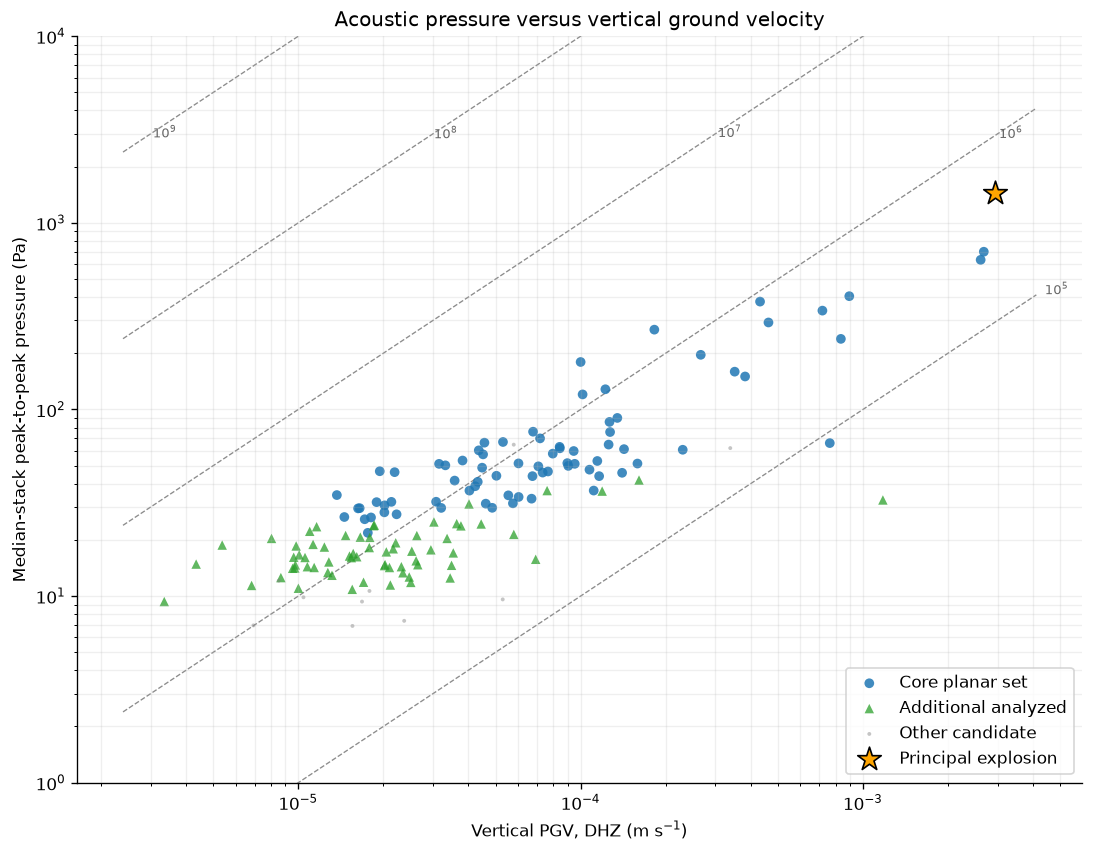

In [7]:
valid_vertical = measurements.loc[
    np.isfinite(measurements["acoustic_stack_peak_to_peak_pa"])
    & (measurements["acoustic_stack_peak_to_peak_pa"] > 0)
    & np.isfinite(measurements["pgv_hhz_mps"])
    & (measurements["pgv_hhz_mps"] > 0)
].copy()

fig, ax = plt.subplots(figsize=(9, 7), constrained_layout=True)
for tier, style in TIER_STYLE.items():
    subset = valid_vertical.loc[valid_vertical["selection_tier"] == tier]
    if subset.empty:
        continue
    ax.scatter(
        subset["pgv_hhz_mps"],
        subset["acoustic_stack_peak_to_peak_pa"],
        edgecolor="none",
        **style,
    )

xmin = valid_vertical["pgv_hhz_mps"].min()
xmax = valid_vertical["pgv_hhz_mps"].max()
xline = np.logspace(np.log10(xmin / 1.4), np.log10(xmax * 1.4), 300)

for ratio in RATIO_GUIDES_PA_PER_MPS:
    yline = ratio * xline
    ax.plot(xline, yline, color="0.55", lw=0.8, ls="--", zorder=0)
    inside = (
        (yline >= valid_vertical["acoustic_stack_peak_to_peak_pa"].min() / 2)
        & (yline <= valid_vertical["acoustic_stack_peak_to_peak_pa"].max() * 2)
    )
    if np.any(inside):
        idx = np.flatnonzero(inside)[-1]
        ax.text(
            xline[idx], yline[idx],
            f"  $10^{{{int(np.log10(ratio))}}}$",
            color="0.4", fontsize=8,
        )

principal = valid_vertical.loc[
    valid_vertical["event_number"] == PRINCIPAL_EXPLOSION_EVENT_NUMBER
]
if not principal.empty:
    row = principal.iloc[0]
    ax.scatter(
        row["pgv_hhz_mps"],
        row["acoustic_stack_peak_to_peak_pa"],
        marker="*", s=220, facecolor="orange", edgecolor="black",
        zorder=5, label="Principal explosion",
    )

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_ylim(1, 10000)
ax.set_xlabel("Vertical PGV, DHZ (m s$^{-1}$)")
ax.set_ylabel("Median-stack peak-to-peak pressure (Pa)")
ax.set_title("Acoustic pressure versus vertical ground velocity")
ax.grid(True, which="both", alpha=0.2)
ax.legend()
fig.savefig(
    FIGURE_DIR / "peak_to_peak_pressure_vs_vertical_pgv.png",
    bbox_inches="tight",
)
plt.show()


## SNR, window capture, and the apparent coupling relationship

The low-amplitude part of the pressure–PGV diagram may be controlled by acoustic
and seismic noise floors rather than a change in source physics. The following
diagnostics therefore display the dimensional pressure/PGV ratio against PGV,
colored separately by seismic and acoustic SNR.

The provisional high-quality regression subset requires:

- vector PGV SNR ≥ 5;
- acoustic stack peak-to-peak SNR ≥ 5;
- event-window PGV ≥ 70% of the maximum PGV in the saved segment.

These are configurable quality criteria, not proposed catalogue boundaries.


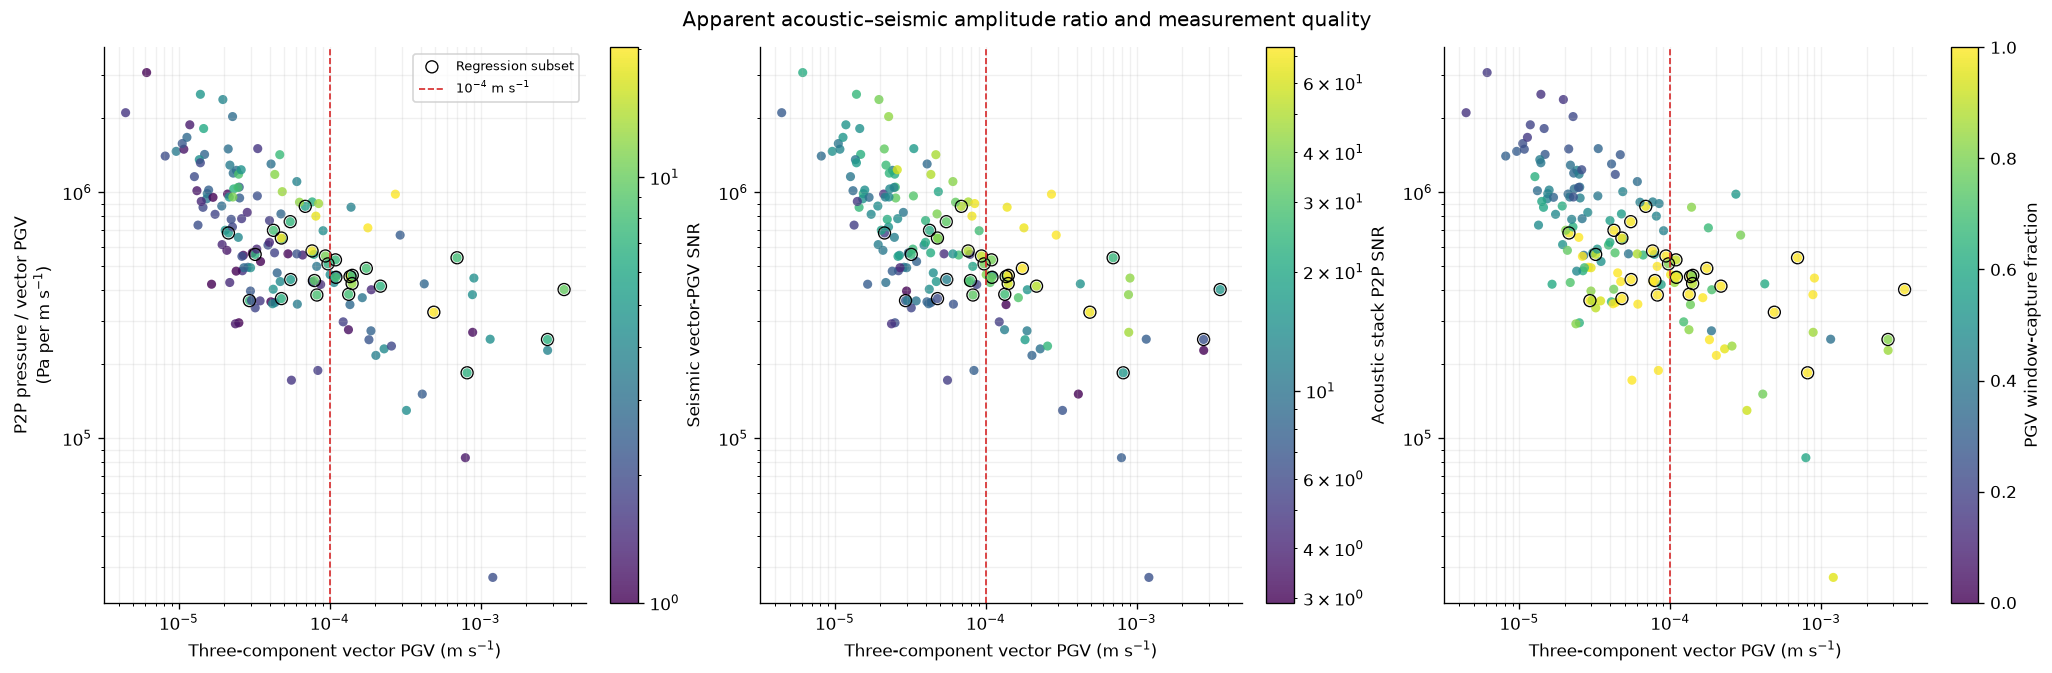

,pgv_vector_snr,acoustic_stack_p2p_snr,pgv_window_capture_fraction,p2p_pressure_to_vector_pgv
passes_regression_quality,,,,
False,2.480865,14.334155,0.569254,652244.031590
True,7.911191,32.850281,1.000000,454417.153448


In [8]:
MIN_REGRESSION_SEISMIC_SNR = 5.0
MIN_REGRESSION_ACOUSTIC_SNR = 5.0
MIN_REGRESSION_CAPTURE_FRACTION = 0.70

ratio_valid = measurements.loc[
    np.isfinite(measurements["pgv_vector_mps"])
    & (measurements["pgv_vector_mps"] > 0)
    & np.isfinite(measurements["p2p_pressure_to_vector_pgv"])
    & (measurements["p2p_pressure_to_vector_pgv"] > 0)
].copy()

ratio_valid["passes_regression_quality"] = (
    (ratio_valid["pgv_vector_snr"] >= MIN_REGRESSION_SEISMIC_SNR)
    & (ratio_valid["acoustic_stack_p2p_snr"] >= MIN_REGRESSION_ACOUSTIC_SNR)
    & (ratio_valid["pgv_window_capture_fraction"] >= MIN_REGRESSION_CAPTURE_FRACTION)
)
measurements["passes_regression_quality"] = measurements["event_number"].isin(
    ratio_valid.loc[ratio_valid["passes_regression_quality"], "event_number"]
)
measurements.to_csv(OUTPUT_ROOT / "event_acoustic_seismic_amplitudes.csv", index=False)

fig, axes = plt.subplots(1, 3, figsize=(17, 5.5), constrained_layout=True)
color_specs = [
    ("pgv_vector_snr", "Seismic vector-PGV SNR"),
    ("acoustic_stack_p2p_snr", "Acoustic stack P2P SNR"),
    ("pgv_window_capture_fraction", "PGV window-capture fraction"),
]

for ax, (column, label) in zip(axes, color_specs):
    values = ratio_valid[column].to_numpy(float)
    finite_positive = values[np.isfinite(values) & (values > 0)]
    if column.endswith("snr") and finite_positive.size:
        vmin = max(1.0, float(np.nanpercentile(finite_positive, 2)))
        vmax = max(vmin * 1.01, float(np.nanpercentile(finite_positive, 98)))
        norm = LogNorm(vmin=vmin, vmax=vmax)
    else:
        norm = plt.Normalize(vmin=0, vmax=1)
    artist = ax.scatter(
        ratio_valid["pgv_vector_mps"],
        ratio_valid["p2p_pressure_to_vector_pgv"],
        c=ratio_valid[column], cmap="viridis", norm=norm,
        s=30, alpha=0.8, edgecolor="none",
    )
    selected = ratio_valid.loc[ratio_valid["passes_regression_quality"]]
    ax.scatter(
        selected["pgv_vector_mps"], selected["p2p_pressure_to_vector_pgv"],
        facecolor="none", edgecolor="black", s=52, lw=0.8,
        label="Regression subset",
    )
    ax.axvline(1e-4, color="tab:red", ls="--", lw=1, label="$10^{-4}$ m s$^{-1}$")
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("Three-component vector PGV (m s$^{-1}$)")
    ax.grid(True, which="both", alpha=0.18)
    fig.colorbar(artist, ax=ax, label=label)

axes[0].set_ylabel("P2P pressure / vector PGV\n(Pa per m s$^{-1}$)")
axes[0].legend(fontsize=8)
fig.suptitle("Apparent acoustic–seismic amplitude ratio and measurement quality")
fig.savefig(FIGURE_DIR / "pressure_pgv_ratio_vs_pgv_colored_by_quality.png", bbox_inches="tight")
plt.show()

display(ratio_valid.groupby("passes_regression_quality")[[
    "pgv_vector_snr", "acoustic_stack_p2p_snr", "pgv_window_capture_fraction",
    "p2p_pressure_to_vector_pgv",
]].median())


## High-quality log–log regression

For the high-quality subset, fit

\[
\log_{10}(p_{p2p})=a+b\log_{10}(\mathrm{PGV}_{3C}).
\]

A slope statistically consistent with one supports an approximately constant
pressure/PGV amplitude ratio over the resolved range. This ordinary least-squares
fit treats PGV as the predictor and does not account for censoring or uncertainty
in both variables; it is an initial descriptive test rather than the final
inferential model.


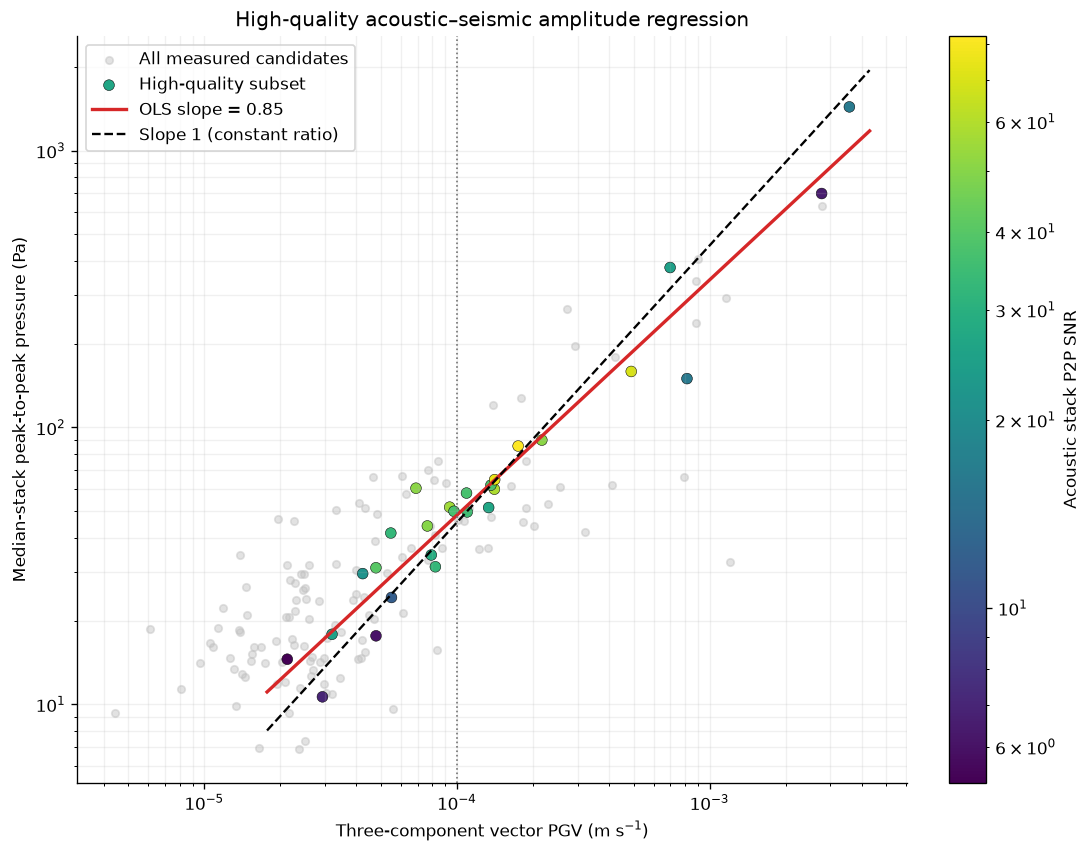

,0
n_events,27
intercept_log10_pa,5.081851
slope,0.84957
slope_standard_error,0.042122
slope_bootstrap_ci_low,0.721089
slope_bootstrap_ci_high,0.945735
r_value,0.97062
r_squared,0.942102
p_value_for_zero_slope,0.0
median_pressure_pgv_ratio,454417.153448


In [9]:
regression_events = ratio_valid.loc[ratio_valid["passes_regression_quality"]].copy()

if len(regression_events) < 3:
    print("Too few high-quality events for regression")
    regression_summary = pd.DataFrame()
else:
    x = np.log10(regression_events["pgv_vector_mps"].to_numpy(float))
    y = np.log10(regression_events["acoustic_stack_peak_to_peak_pa"].to_numpy(float))
    fit = linregress(x, y)

    # Nonparametric event bootstrap for a descriptive slope interval.
    rng = np.random.default_rng(20260716)
    bootstrap_slopes = []
    for _ in range(5000):
        indices = rng.integers(0, len(x), len(x))
        if np.unique(x[indices]).size < 2:
            continue
        bootstrap_slopes.append(linregress(x[indices], y[indices]).slope)
    slope_ci = np.nanpercentile(bootstrap_slopes, [2.5, 97.5])

    x_plot = np.linspace(x.min() - 0.08, x.max() + 0.08, 300)
    y_fit = fit.intercept + fit.slope * x_plot
    median_log_ratio = np.nanmedian(y - x)
    y_slope_one = median_log_ratio + x_plot

    fig, ax = plt.subplots(figsize=(9, 7), constrained_layout=True)
    ax.scatter(
        ratio_valid["pgv_vector_mps"], ratio_valid["acoustic_stack_peak_to_peak_pa"],
        color="0.75", s=20, alpha=0.45, label="All measured candidates",
    )
    scatter = ax.scatter(
        regression_events["pgv_vector_mps"],
        regression_events["acoustic_stack_peak_to_peak_pa"],
        c=regression_events["acoustic_stack_p2p_snr"], cmap="viridis",
        norm=LogNorm(), s=42, edgecolor="black", lw=0.3,
        label="High-quality subset",
    )
    ax.plot(10 ** x_plot, 10 ** y_fit, color="tab:red", lw=2,
            label=f"OLS slope = {fit.slope:.2f}")
    ax.plot(10 ** x_plot, 10 ** y_slope_one, color="black", ls="--", lw=1.4,
            label="Slope 1 (constant ratio)")
    ax.axvline(1e-4, color="0.45", ls=":", lw=1)
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("Three-component vector PGV (m s$^{-1}$)")
    ax.set_ylabel("Median-stack peak-to-peak pressure (Pa)")
    ax.set_title("High-quality acoustic–seismic amplitude regression")
    ax.grid(True, which="both", alpha=0.18)
    ax.legend()
    fig.colorbar(scatter, ax=ax, label="Acoustic stack P2P SNR")
    fig.savefig(FIGURE_DIR / "high_quality_pressure_pgv_regression.png", bbox_inches="tight")
    plt.show()

    regression_summary = pd.DataFrame([{
        "n_events": len(regression_events),
        "intercept_log10_pa": fit.intercept,
        "slope": fit.slope,
        "slope_standard_error": fit.stderr,
        "slope_bootstrap_ci_low": slope_ci[0],
        "slope_bootstrap_ci_high": slope_ci[1],
        "r_value": fit.rvalue,
        "r_squared": fit.rvalue ** 2,
        "p_value_for_zero_slope": fit.pvalue,
        "median_pressure_pgv_ratio": 10 ** median_log_ratio,
        "slope_one_inside_bootstrap_ci": bool(slope_ci[0] <= 1.0 <= slope_ci[1]),
    }])
    regression_summary.to_csv(OUTPUT_ROOT / "pressure_pgv_regression_summary.csv", index=False)
    display(regression_summary.T)


## Component PGV and measurement diagnostics

These plots check whether one seismic component dominates and whether the chosen
event interval excludes a larger motion elsewhere in the saved segment. Large
differences between event-window and entire-segment PGV should be reviewed before
physical interpretation.


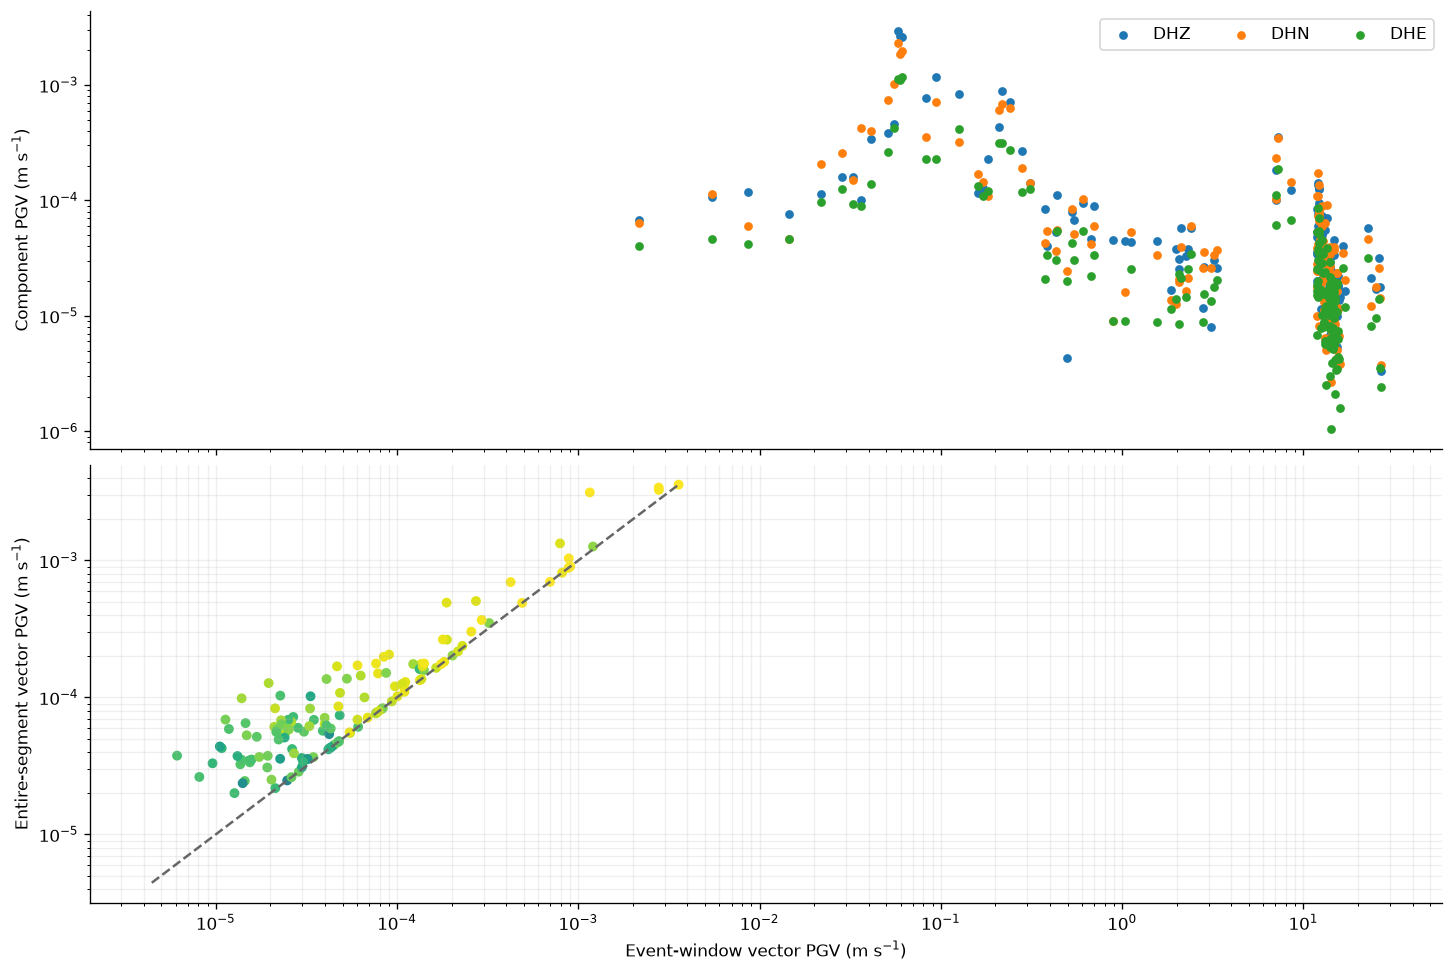

In [10]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True, constrained_layout=True)
axes[0].scatter(measurements["elapsed_time_min"], measurements["pgv_hhz_mps"], s=18, label="DHZ")
axes[0].scatter(measurements["elapsed_time_min"], measurements["pgv_hhn_mps"], s=18, label="DHN")
axes[0].scatter(measurements["elapsed_time_min"], measurements["pgv_hhe_mps"], s=18, label="DHE")
axes[0].set_yscale("log")
axes[0].set_ylabel("Component PGV (m s$^{-1}$)")
axes[0].legend(ncol=3)

axes[1].scatter(
    measurements["pgv_vector_mps"], measurements["pgv_entire_segment_vector_mps"],
    c=measurements.get("maximum_coherence_score", pd.Series(np.nan, index=measurements.index)),
    cmap="viridis", vmin=0, vmax=1, s=24,
)
finite = measurements[["pgv_vector_mps", "pgv_entire_segment_vector_mps"]].to_numpy(float)
positive = finite[np.isfinite(finite) & (finite > 0)]
if positive.size:
    lo, hi = positive.min(), positive.max()
    axes[1].plot([lo, hi], [lo, hi], color="0.4", ls="--")
axes[1].set_xscale("log")
axes[1].set_yscale("log")
axes[1].set_xlabel("Event-window vector PGV (m s$^{-1}$)")
axes[1].set_ylabel("Entire-segment vector PGV (m s$^{-1}$)")
axes[1].grid(True, which="both", alpha=0.2)

fig.savefig(FIGURE_DIR / "pgv_component_and_window_diagnostics.png", bbox_inches="tight")
plt.show()


## Optional per-event diagnostic plots

Each diagnostic shows the locally baseline-corrected seismic components and
vector magnitude. The shaded interval is the interval used for catalogue PGV;
the dotted interval is the noise window. These figures are intended for auditing
the measurement, especially for the principal explosion and unusually large
pressure/PGV ratios.


In [11]:
if MAKE_EVENT_DIAGNOSTICS:
    rows_to_plot = measurements.sort_values("event_number")
    if MAX_DIAGNOSTIC_EVENTS is not None:
        rows_to_plot = rows_to_plot.head(MAX_DIAGNOSTIC_EVENTS)

    for row in rows_to_plot.itertuples(index=False):
        diagnostic = diagnostic_data.get(int(row.event_number))
        if diagnostic is None:
            continue
        times = diagnostic["times_s"]
        fig, axes = plt.subplots(4, 1, figsize=(10, 8), sharex=True, constrained_layout=True)
        for ax, channel in zip(axes[:3], SEISMIC_CHANNELS):
            ax.plot(times, diagnostic["corrected"][channel], color="black", lw=0.8)
            ax.set_ylabel(f"{channel}\n(m s$^{{-1}}$)")
        axes[3].plot(times, diagnostic["vector_velocity"], color="tab:blue", lw=0.9)
        axes[3].set_ylabel("Vector\n(m s$^{-1}$)")
        axes[3].set_xlabel("Time relative to reduced event time (s)")
        for ax in axes:
            ax.axvspan(*NOISE_WINDOW_S, color="0.7", alpha=0.18)
            ax.axvspan(*diagnostic["signal_window"], color="orange", alpha=0.15)
            ax.axhline(0, color="0.6", lw=0.5)
        fig.suptitle(
            f"Event {int(row.event_number):03d}: seismic PGV audit\n"
            f"PGV={row.pgv_vector_mps:.3g} m/s; p2p={row.acoustic_stack_peak_to_peak_pa:.3g} Pa; "
            f"ratio={row.p2p_pressure_to_vector_pgv:.3g} Pa per (m/s)"
        )
        fig.savefig(DIAGNOSTIC_DIR / f"event_{int(row.event_number):03d}_pgv.png", bbox_inches="tight")
        plt.close(fig)
    print("Diagnostic plots written to", DIAGNOSTIC_DIR)


Diagnostic plots written to /Users/thompsong/Library/CloudStorage/Box-Box/thompsong/3_Project_Documents/NASAprojects/201602_Rocket_Seismology/writing/spacex_paper/data/outputs2/event_amplitude_coupling/event_diagnostics


## Summary and interpretation safeguards

- `peak_to_peak_pa / pgv_vector_mps` is a **dimensional amplitude ratio**. It is
  not VASR and should not be described as an energy-partition ratio.
- The seismic signals are expected to be dominated by ground-coupled airwaves;
  PGV does not necessarily represent direct elastic energy from the source.
- The fixed 1.42 km pressure reduction is an optional first-order comparison.
  Event-specific source distances should replace it if spherical/source-location
  analysis establishes meaningful source displacement.
- Events failing the planar filter remain visible so the amplitude distribution
  is not artificially truncated at an arbitrary SNR or amplitude boundary.


In [12]:
summary = {
    "events_in_catalogue": int(len(measurements)),
    "events_with_pgv": int(measurements["pgv_vector_mps"].notna().sum()),
    "median_peak_to_peak_pa": float(measurements["acoustic_stack_peak_to_peak_pa"].median()),
    "median_vector_pgv_mps": float(measurements["pgv_vector_mps"].median()),
    "median_p2p_pressure_to_vector_pgv": float(measurements["p2p_pressure_to_vector_pgv"].median()),
    "principal_explosion_event_number": PRINCIPAL_EXPLOSION_EVENT_NUMBER,
    "noise_window_s": list(NOISE_WINDOW_S),
    "principal_signal_window_s": list(PRINCIPAL_SIGNAL_WINDOW_S),
    "pressure_reduction_distance_m": REFERENCE_SOURCE_DISTANCE_M,
    "ratio_units": "Pa / (m s^-1)",
}
(OUTPUT_ROOT / "event_amplitude_coupling_summary.json").write_text(json.dumps(summary, indent=2))

display(pd.Series(summary, name="value").to_frame())
print("Primary table:", OUTPUT_ROOT / "event_acoustic_seismic_amplitudes.csv")
print("Figures:", FIGURE_DIR)


,value
events_in_catalogue,153
events_with_pgv,153
median_peak_to_peak_pa,29.576925
median_vector_pgv_mps,0.000042
median_p2p_pressure_to_vector_pgv,567646.591505
principal_explosion_event_number,13
noise_window_s,"[-0.18, -0.05]"
principal_signal_window_s,"[-0.04, 0.35]"
pressure_reduction_distance_m,1419.886511
ratio_units,Pa / (m s^-1)


Primary table: /Users/thompsong/Library/CloudStorage/Box-Box/thompsong/3_Project_Documents/NASAprojects/201602_Rocket_Seismology/writing/spacex_paper/data/outputs2/event_amplitude_coupling/event_acoustic_seismic_amplitudes.csv
Figures: /Users/thompsong/Library/CloudStorage/Box-Box/thompsong/3_Project_Documents/NASAprojects/201602_Rocket_Seismology/writing/spacex_paper/data/outputs2/event_amplitude_coupling/figures
